# Knox Design Analysis Notebook

Spring 2026

EC552 - Computational Synthetic Biology for Engineers

Team Members Names:

# Notes From James

Depending on number of rules, the rule evaluation algorithm can take 10-30 minutes to run. Rule Evaluations are saved in Neo4j, so you do not
need to rerun the rule evaluation algorithm, call getRuleEvaluation with the name of the evaluation (only 2-5 seconds to retrieve).

Run rule evaluations with:
- ruleEvaluateByGroup
- ruleEvaluateByDesigns


Get rule evaluations with
- getRuleEvaluation


Delete rule evaluations with
- deleteRuleEvaluation


This notebook is to serve as a starting point for doing your analysis.

Feel free to change this notebook in any way you see fit.


In [25]:
import requests
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report

In [15]:
url = 'http://localhost:8080'

def ruleEvaluateByGroup(evalName, groupID, ruleGroupID, labelingMethod="sign"):
    """
    API Request to Knox to run Rule Evaluation Algorithm.
    
    Returns:
    metrics (list of pandas DataFrames): purity_metrics, designToRule
    """
    response = requests.post(url + '/rule/evaluate?' + 
                             "evaluationName=" + evalName + '&' + 
                             "designGroupID=" + groupID + '&' +
                             "rulesGroupID=" + ruleGroupID + '&' +
                             "labelingMethod=" + labelingMethod
    )

    return processRuleEval(response)


def ruleEvaluateByDesigns(evalName, designIDs, ruleGroupID, designScores, labelingMethod="sign"):
    designSpaceIDs = listToStringList(designIDs)
    designScoresStr = listToStringList(designScores) # designScores should be a list of strings, may have to convert floats to strings before running

    # Submit Request
    response = requests.post(url + '/rule/evaluate?' + 
                             "evaluationName=" + evalName + '&' + 
                             "designSpaceIDs=" + designSpaceIDs + '&' + 
                             "rulesGroupID=" + ruleGroupID + '&' + 
                             "designScores=" + designScoresStr + '&' + 
                             "labelingMethod=" + labelingMethod
    )

    return processRuleEval(response)


def getRuleEvaluation(evalName):
    response = requests.get(url + '/rule/getEvaluation?' + "evaluationName=" + evalName)

    return processRuleEval(response)


def deleteRuleEvaluation(evalName):
    response = requests.delete(url + '/rule?' + "evaluationName=" + evalName)

    if not response.text:
        return f'"{evalName}" Sucessfully Deleted'
    else:
        return response.text
    

def processRuleEval(response):
    # Change to Pandas DataFrame
    json_data = json.loads(response.text)

    purity_metrics_df = pd.DataFrame(json_data["evaluationResults"]).T

    designToRule_df = pd.DataFrame(json_data["designToRule"], index=json_data["designToRule"]["designIDs"])
    cols = designToRule_df.columns.to_list()
    cols.remove("labels")
    cols.remove("scores")
    cols.remove("designIDs")
    cols = ["labels", "scores"] + cols
    designToRule_df = designToRule_df[cols]

    return purity_metrics_df.sort_values("impact"), designToRule_df.sort_values("scores")


def listToStringList(list_input):
    return ",".join(list_input)
    


In [16]:
def exampleTree(X, y, **kwargs):
    """Binary / multi-class classification tree."""
    dt_clf = tree.DecisionTreeClassifier(
        splitter=kwargs.get('splitter', 'best'),
        max_depth=kwargs.get('max_depth', None),
        min_samples_split=kwargs.get('min_samples_split', 400),
        min_samples_leaf=kwargs.get('min_samples_leaf', 200),
        max_features=kwargs.get('max_features', None),
        max_leaf_nodes=kwargs.get('max_leaf_nodes', None)
    )
    dt_clf = dt_clf.fit(X, y)
    return dt_clf


def regressionTree(X, y, **kwargs):
    """Regression tree predicting continuous scores."""
    dt_reg = tree.DecisionTreeRegressor(
        splitter=kwargs.get('splitter', 'best'),
        max_depth=kwargs.get('max_depth', None),
        min_samples_split=kwargs.get('min_samples_split', 400),
        min_samples_leaf=kwargs.get('min_samples_leaf', 200),
        max_features=kwargs.get('max_features', None),
        max_leaf_nodes=kwargs.get('max_leaf_nodes', None)
    )
    dt_reg = dt_reg.fit(X, y)
    return dt_reg


def plotTree(model, feature_names, class_names=None, title="Decision Tree", save_path=None, figsize=(28, 12)):
    """Plot and optionally save a fitted sklearn decision tree."""
    fig, ax = plt.subplots(figsize=figsize)
    tree.plot_tree(
        model,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        rounded=True,
        fontsize=7,
        ax=ax
    )
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


In [17]:
# Use this for (gnn_predicted_scores.csv) designs already have the attached scores

evalName      = 'hw1_eval'        # any unique name — gets saved in Neo4j
groupID       = 'hw1_designs'     # Group ID you used when importing the 3 CSVs
ruleGroupID   = 'hw1_rules'       # Group ID you used in GOLDBAR Generator
labelingMethod = 'median'

purity_metrics_df, designToRule_df = ruleEvaluateByGroup(evalName, groupID, ruleGroupID, labelingMethod)

In [ ]:
#purity_metrics_df, designToRule_df = getRuleEvaluation('hw1_eval')

In [21]:
purity_metrics_df.to_csv("purity_metrics.csv")

In [20]:
designToRule_df.to_csv("designToRule.csv")


In [22]:
feature_names = designToRule_df.columns.to_list()[2:]   # rule column names
X             = designToRule_df.iloc[:, 2:].to_numpy(dtype=int)   # 0=kept, 1=eliminated
y_labels      = designToRule_df["labels"].to_numpy(dtype=int)     # 0=poor, 1=good (binary)
y_scores      = designToRule_df["scores"].to_numpy(dtype=float)   # raw Cello score

print(f"Features (X):  {X.shape}")
print(f"Labels  (y):   {y_labels.shape}  |  unique: {np.unique(y_labels)}")
print(f"Scores  (y):   {y_scores.shape}  |  range [{y_scores.min():.3f}, {y_scores.max():.3f}]")
print(f"Class balance — poor (0): {(y_labels==0).sum()}  |  good (1): {(y_labels==1).sum()}")

Features (X):  (7992, 5)
Labels  (y):   (7992,)  |  unique: [0 1]
Scores  (y):   (7992,)  |  range [-0.955, 3.462]
Class balance — poor (0): 3996  |  good (1): 3996


In [30]:
RANDOM_STATE = 42
TEST_SIZE    = 0.30

# ── For binary classification and regression ──
X_train, X_test, y_train_lbl, y_test_lbl, y_train_scr, y_test_scr = train_test_split(
    X, y_labels, y_scores, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# ── For multi-class: bin scores into quartiles ──
q1, q2, q3 = np.quantile(y_scores, [0.25, 0.50, 0.75])
print(f"Score quartiles  Q1={q1:.3f}  Q2(median)={q2:.3f}  Q3={q3:.3f}")

def bin_to_quartile(s):
    if   s <= q1: return 0  # awful
    elif s <= q2: return 1  # poor
    elif s <= q3: return 2  # good
    else:         return 3  # great

y_multi = np.array([bin_to_quartile(s) for s in y_scores])
class_names_multi = ["awful", "poor", "good", "great"]

_, _, y_train_multi, y_test_multi = train_test_split(
    X, y_multi, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

Score quartiles  Q1=-0.628  Q2(median)=-0.077  Q3=1.708
Train size: 5594  |  Test size: 2398


In [ ]:
# Tree 1: Binary Classification
clf_binary = tree.DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,    # ← fixed (was 400)
    min_samples_leaf=5,      # ← fixed (was 200)
    random_state=RANDOM_STATE
)
clf_binary.fit(X_train, y_train_lbl)

y_pred_binary = clf_binary.predict(X_test)
print("=" * 55)
print("Tree 1 — Binary Classification")
print(f"  Test Accuracy : {accuracy_score(y_test_lbl, y_pred_binary):.4f}")
print(classification_report(y_test_lbl, y_pred_binary,
      target_names=["poor", "good"], zero_division=0))

# Tree 2: Regression
reg_tree = tree.DecisionTreeRegressor(
    max_depth=4,
    min_samples_split=10,    # ← fixed
    min_samples_leaf=5,      # ← fixed
    random_state=RANDOM_STATE
)
reg_tree.fit(X_train, y_train_scr)

y_pred_reg = reg_tree.predict(X_test)
print("=" * 55)
print("Tree 2 — Regression")
print(f"  Test MSE  : {mean_squared_error(y_test_scr, y_pred_reg):.4f}")
print(f"  Test RMSE : {np.sqrt(mean_squared_error(y_test_scr, y_pred_reg)):.4f}")

# Tree 3: Multi-Class Classification
clf_multi = tree.DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,    # ← fixed
    min_samples_leaf=5,      # ← fixed
    random_state=RANDOM_STATE
)
clf_multi.fit(X_train, y_train_multi)

y_pred_multi = clf_multi.predict(X_test)
print("=" * 55)
print("Tree 3 — Multi-Class Classification")
print(f"  Test Accuracy : {accuracy_score(y_test_multi, y_pred_multi):.4f}")
print(classification_report(y_test_multi, y_pred_multi,
      target_names=class_names_multi, zero_division=0))
print("=" * 55)

Tree 1 — Binary Classification
  Test Accuracy : 0.4921
              precision    recall  f1-score   support

        poor       0.00      0.00      0.00      1218
        good       0.49      1.00      0.66      1180

    accuracy                           0.49      2398
   macro avg       0.25      0.50      0.33      2398
weighted avg       0.24      0.49      0.32      2398

Tree 2 — Regression
  Test MSE  : 1.5577
  Test RMSE : 1.2481
Tree 3 — Multi-Class Classification
  Test Accuracy : 0.2364
              precision    recall  f1-score   support

       awful       0.00      0.00      0.00       645
        poor       0.00      0.00      0.00       573
        good       0.00      0.00      0.00       613
       great       0.24      1.00      0.38       567

    accuracy                           0.24      2398
   macro avg       0.06      0.25      0.10      2398
weighted avg       0.06      0.24      0.09      2398



Saved: tree_binary_classification.png


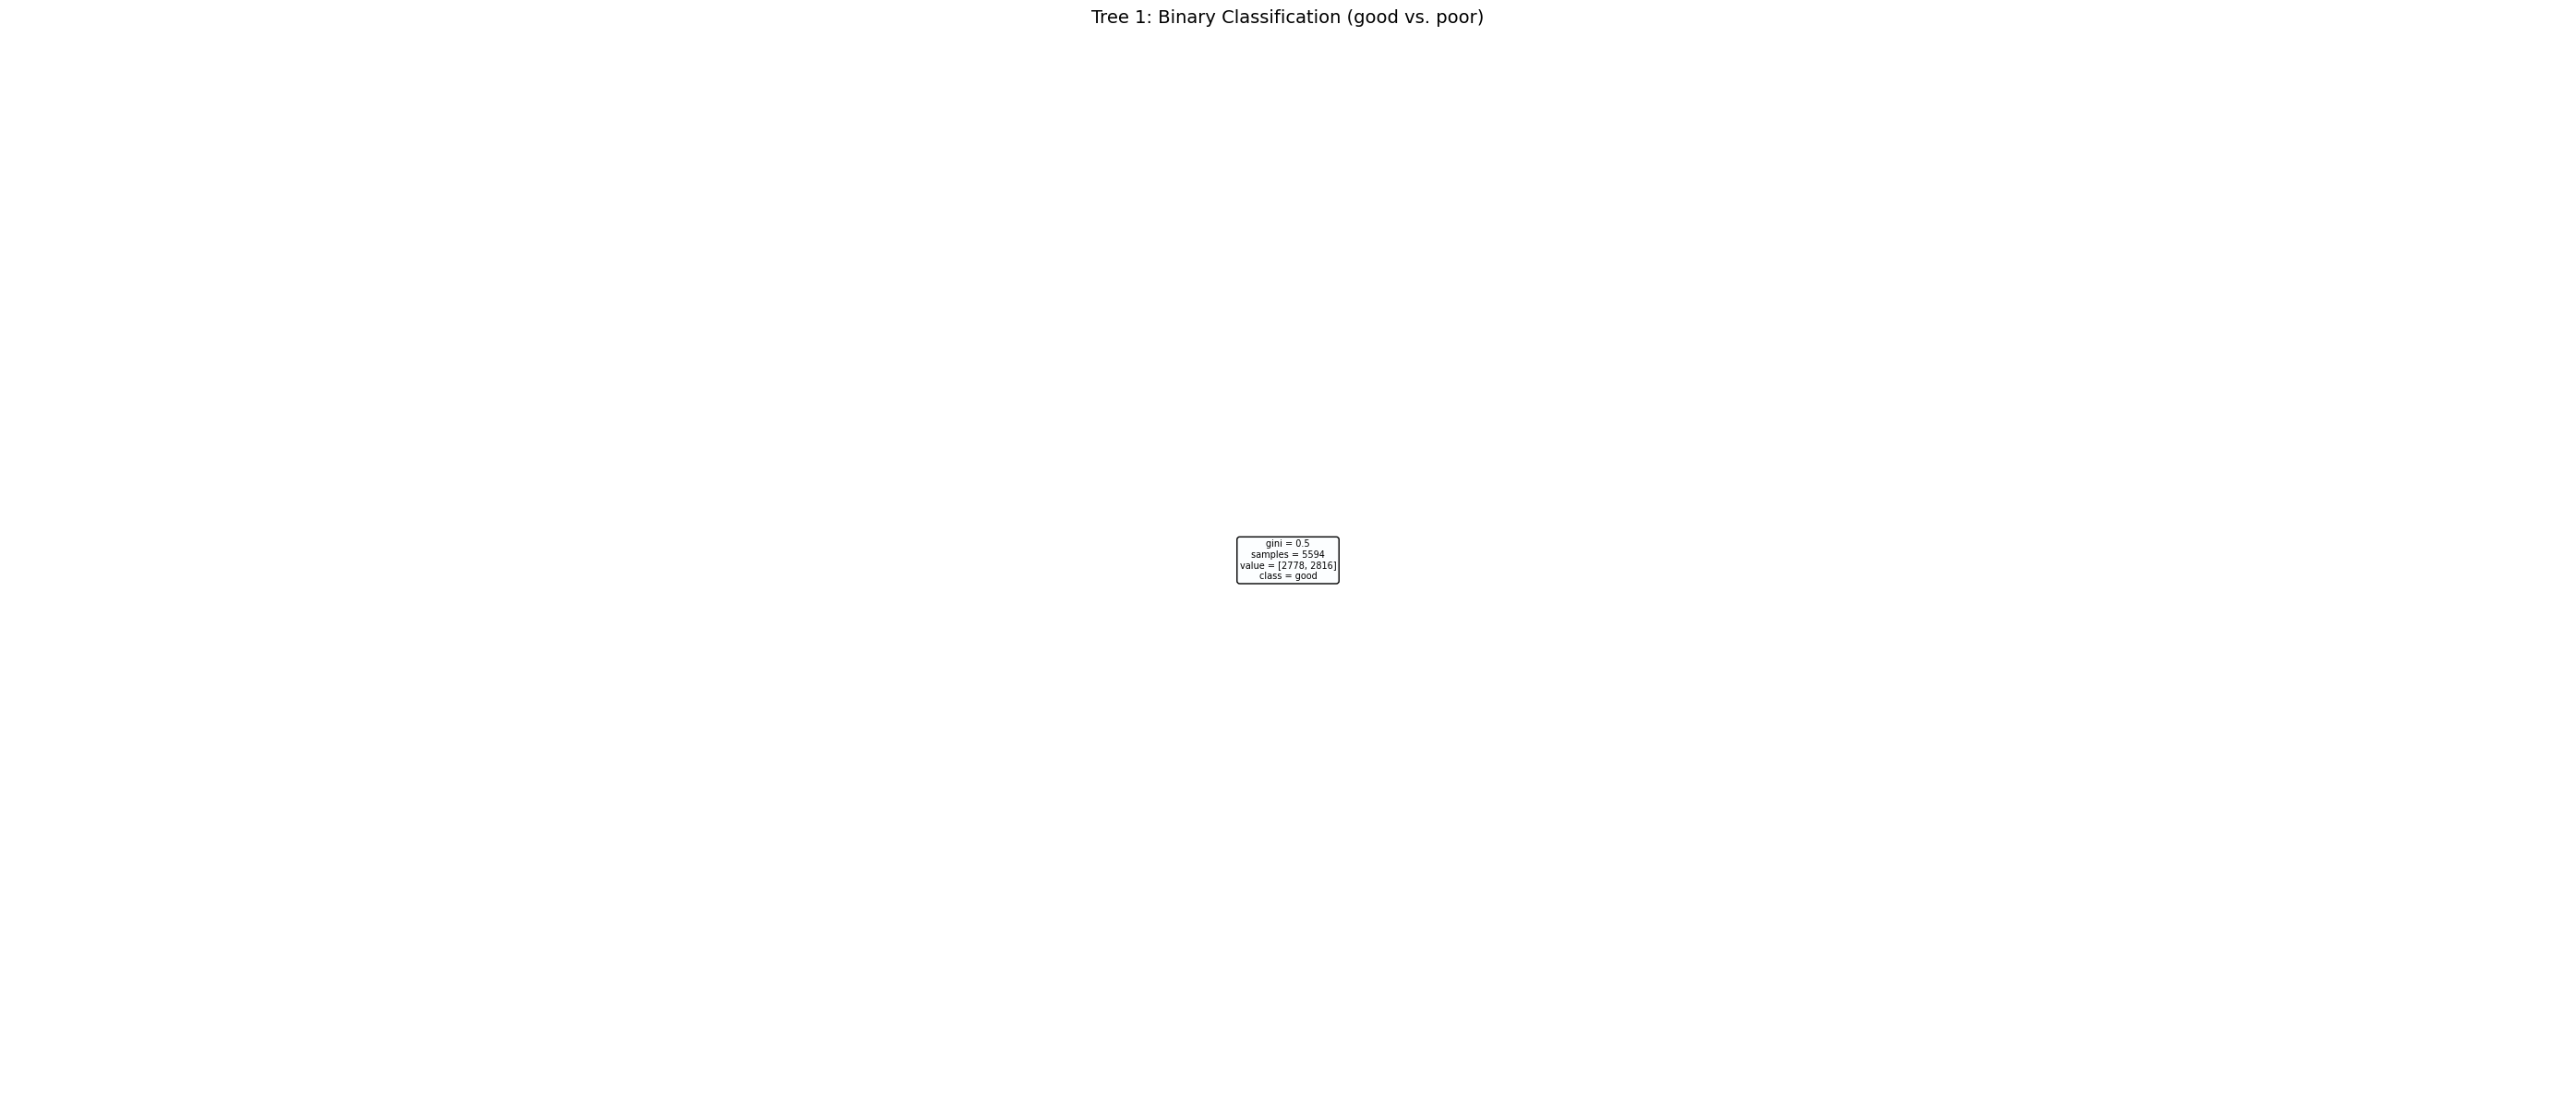

In [32]:
# ── Tree 1: Binary Classification ──
plotTree(
    clf_binary,
    feature_names=feature_names,
    class_names=["poor", "good"],
    title="Tree 1: Binary Classification (good vs. poor)",
    save_path="tree_binary_classification.png",
    figsize=(28, 12)
)

Saved: tree_regression.png


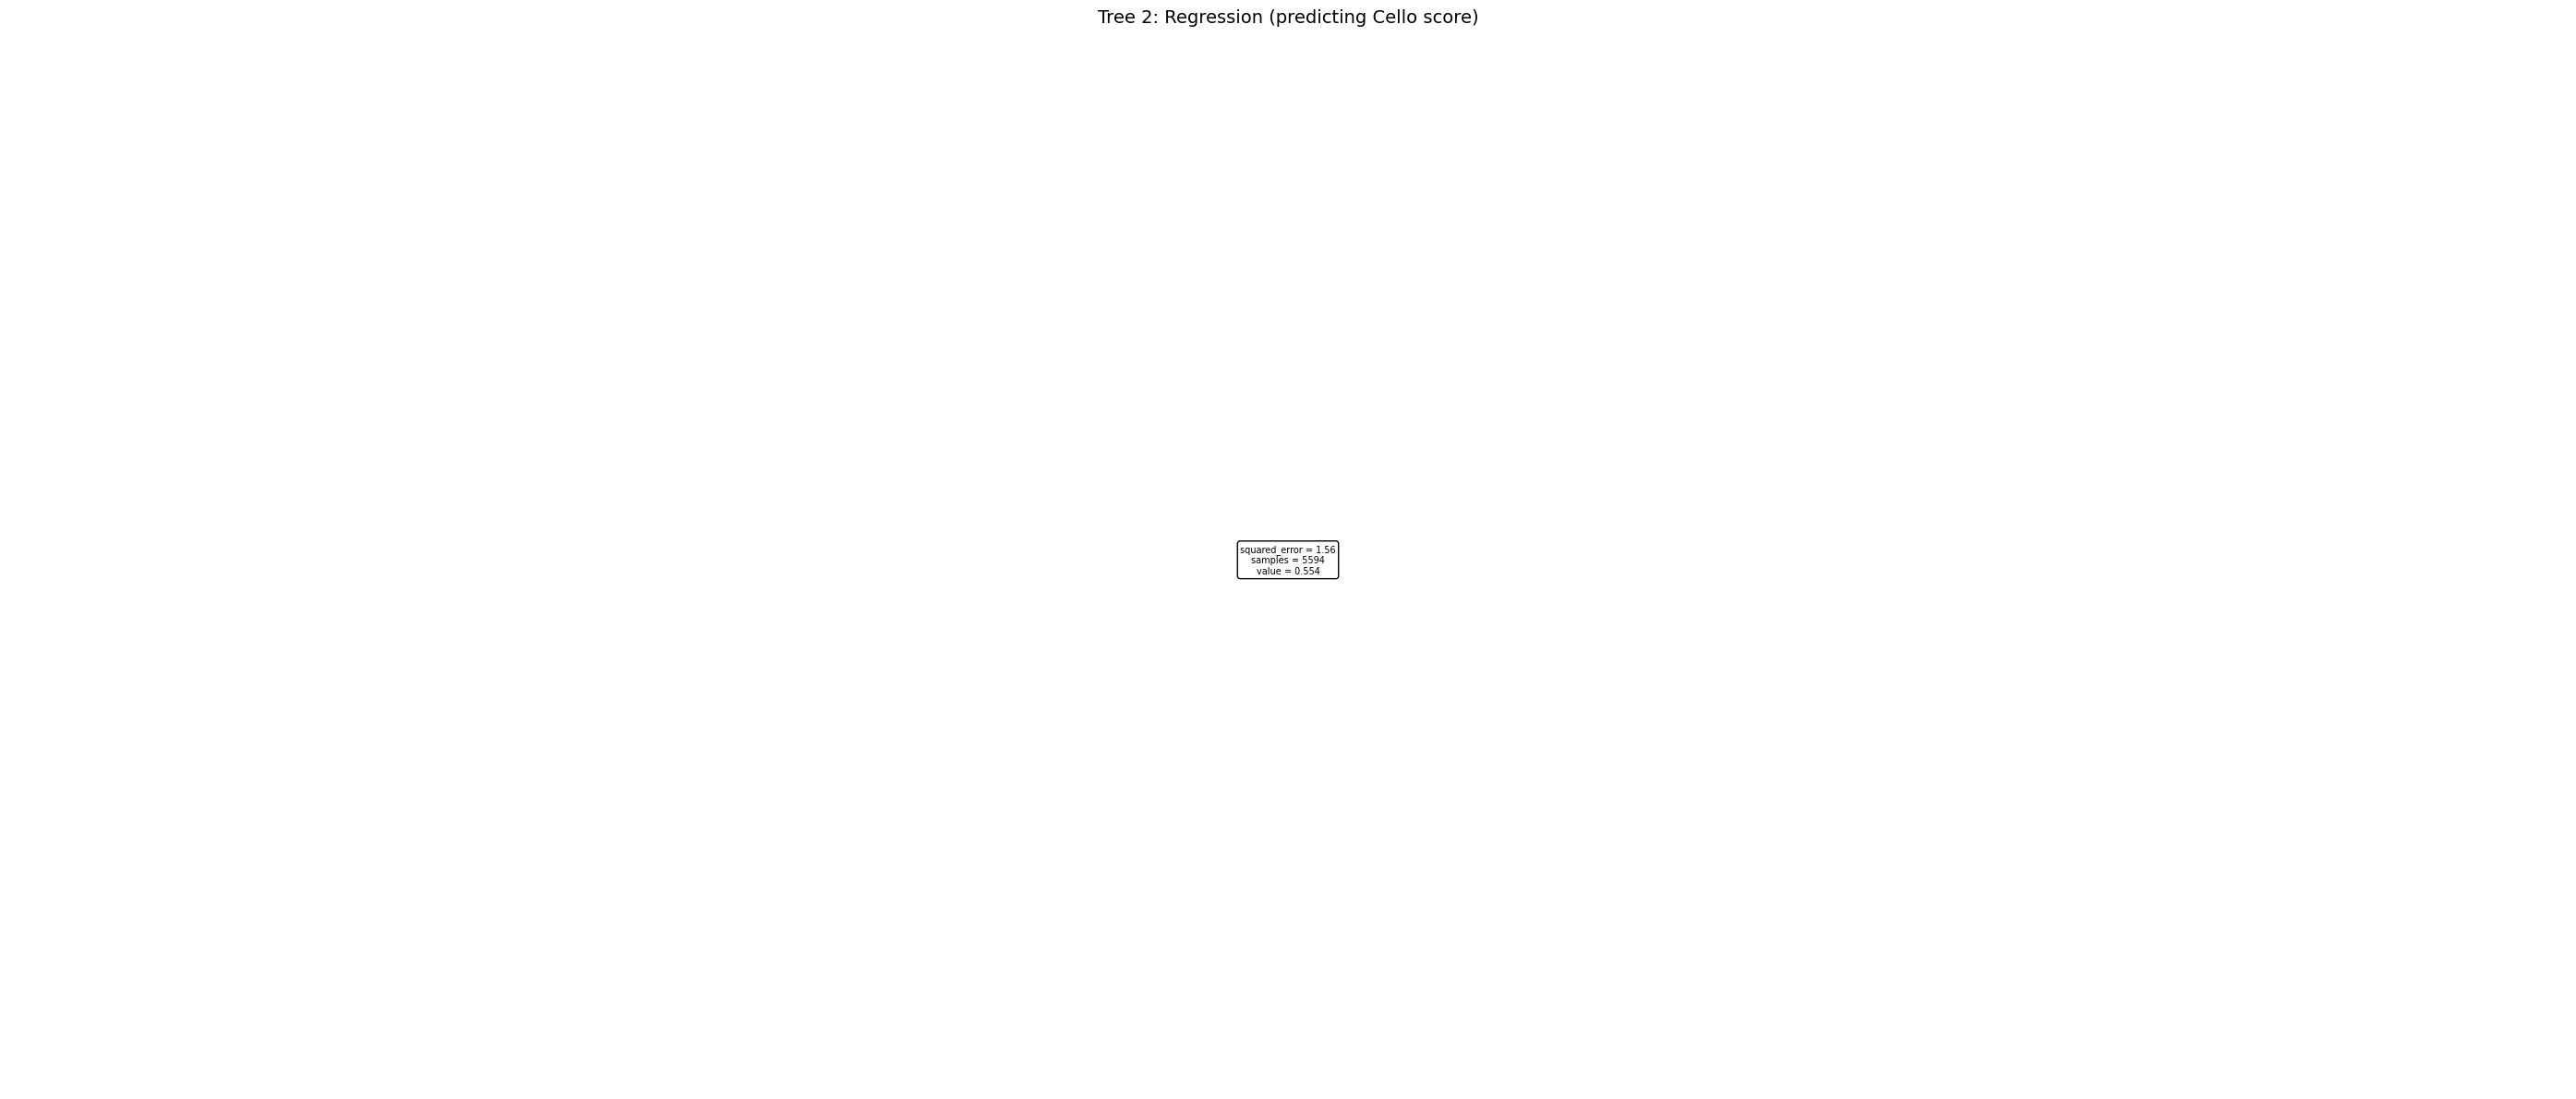

In [33]:
# ── Tree 2: Regression ──
plotTree(
    reg_tree,
    feature_names=feature_names,
    class_names=None,           # no class names for regression
    title="Tree 2: Regression (predicting Cello score)",
    save_path="tree_regression.png",
    figsize=(28, 12)
)

Saved: tree_multiclass.png


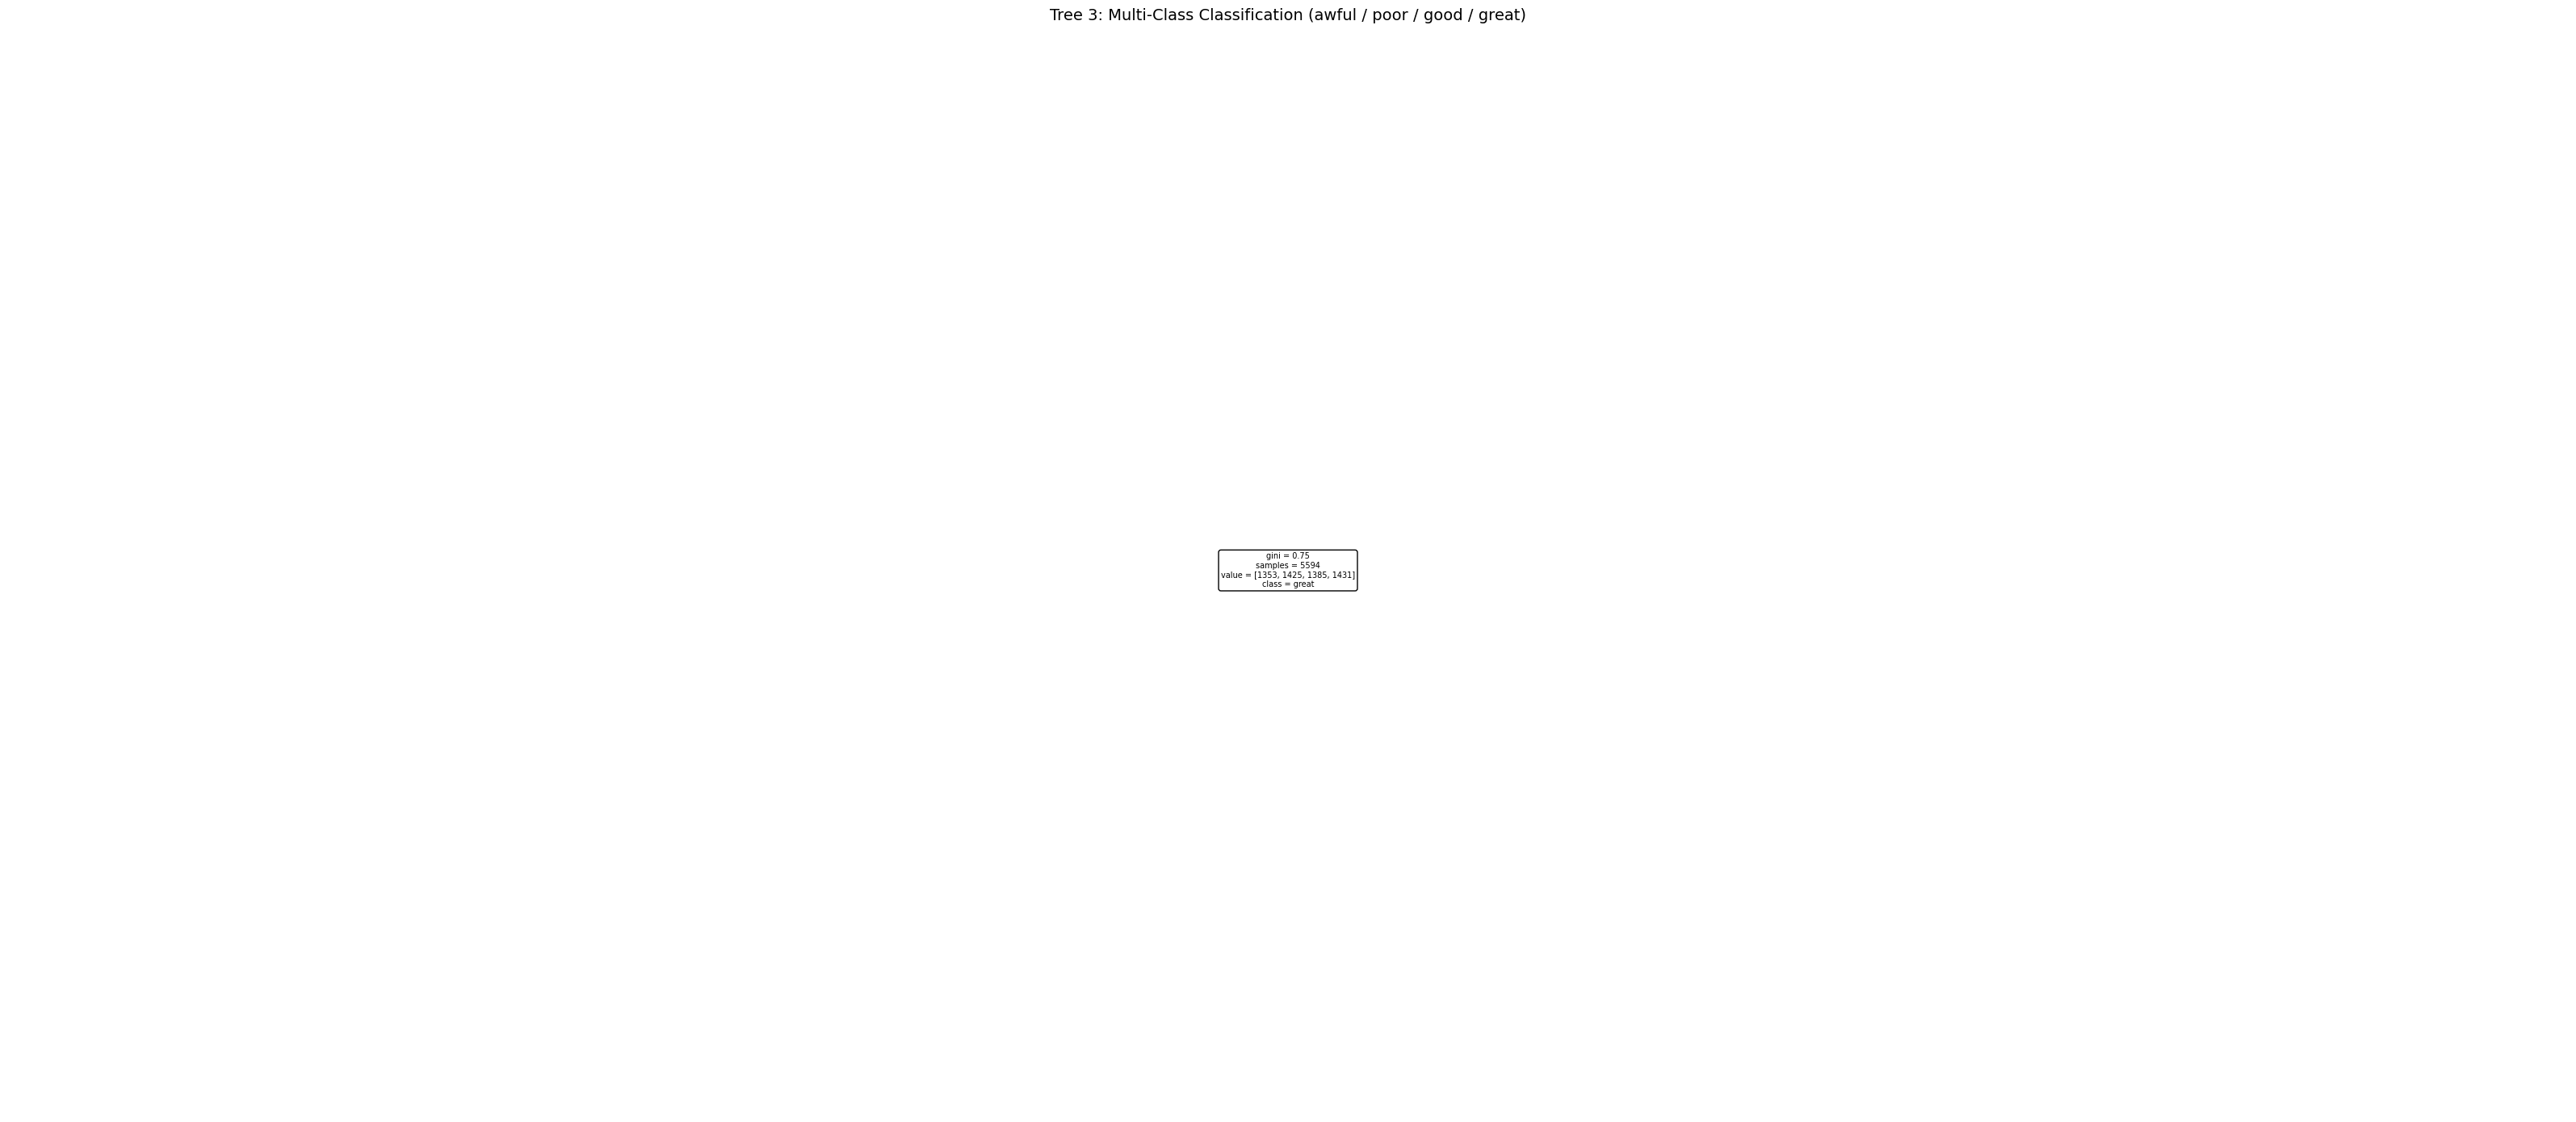

In [29]:
# ── Tree 3: Multi-Class ──
plotTree(
    clf_multi,
    feature_names=feature_names,
    class_names=class_names_multi,
    title="Tree 3: Multi-Class Classification (awful / poor / good / great)",
    save_path="tree_multiclass.png",
    figsize=(32, 14)
)

In [35]:
print("X shape:", X.shape)
print("Unique values in X:", np.unique(X))
print("Column variance (first 10 rules):")
print(pd.DataFrame(X, columns=feature_names).var().head(100))
print("\nLabel counts:", np.unique(y_labels, return_counts=True))

X shape: (7992, 5)
Unique values in X: [1]
Column variance (first 10 rules):
hw1_rules_1_Rule_N_v1     0.0
hw1_rules_Verification    0.0
hw1_rules_2_Rule_N_v1     0.0
hw1_rules_1_Rule_N        0.0
hw1_rules_2_Rule_N        0.0
dtype: float64

Label counts: (array([0, 1]), array([3996, 3996]))


# Extra Credit

In [49]:
true_df = pd.read_csv("true_scores.csv")
transformer_df = pd.read_csv("transformer_predicted_scores.csv")
print("True columns:", true_df.columns.tolist())
print("Transformer columns:", transformer_df.columns.tolist())
print(true_df.head(2))
print(transformer_df.head(2))

True columns: ['weight']
Transformer columns: ['weight']
     weight
0 -0.693147
1 -0.693147
     weight
0 -1.141758
1 -0.182603


In [56]:
# True scores
purity_true, designToRule_true = ruleEvaluateByGroup(
    "eval_true", "hw1_true", "hw1_rules", "median"
)
print("True eval done:", purity_true.shape)

True eval done: (5, 14)


In [57]:
# Transformer scores
purity_transformer, designToRule_transformer = ruleEvaluateByGroup(
    "eval_transformer", "hw1_transformer", "hw1_rules", "median"
)
print("Transformer eval done:", purity_transformer.shape)

Transformer eval done: (5, 14)


In [59]:
# Merge all three
purity_comparison = purity_true[["ruleSpaceID", "impact"]].rename(
    columns={"impact": "true_impact"}
).merge(
    purity_metrics_df[["ruleSpaceID", "impact"]].rename(
        columns={"impact": "gnn_impact"}),
    on="ruleSpaceID"
).merge(
    purity_transformer[["ruleSpaceID", "impact"]].rename(
        columns={"impact": "transformer_impact"}),
    on="ruleSpaceID"
)

# Quantify
diff_gnn   = np.sum(np.abs(
    purity_comparison["gnn_impact"] - purity_comparison["true_impact"]))
diff_trans = np.sum(np.abs(
    purity_comparison["transformer_impact"] - purity_comparison["true_impact"]))


winner = 'GNN' if diff_gnn < diff_trans else 'Transformer'
print(f"\n→ {winner} more closely emulates true grammar")


→ Transformer more closely emulates true grammar


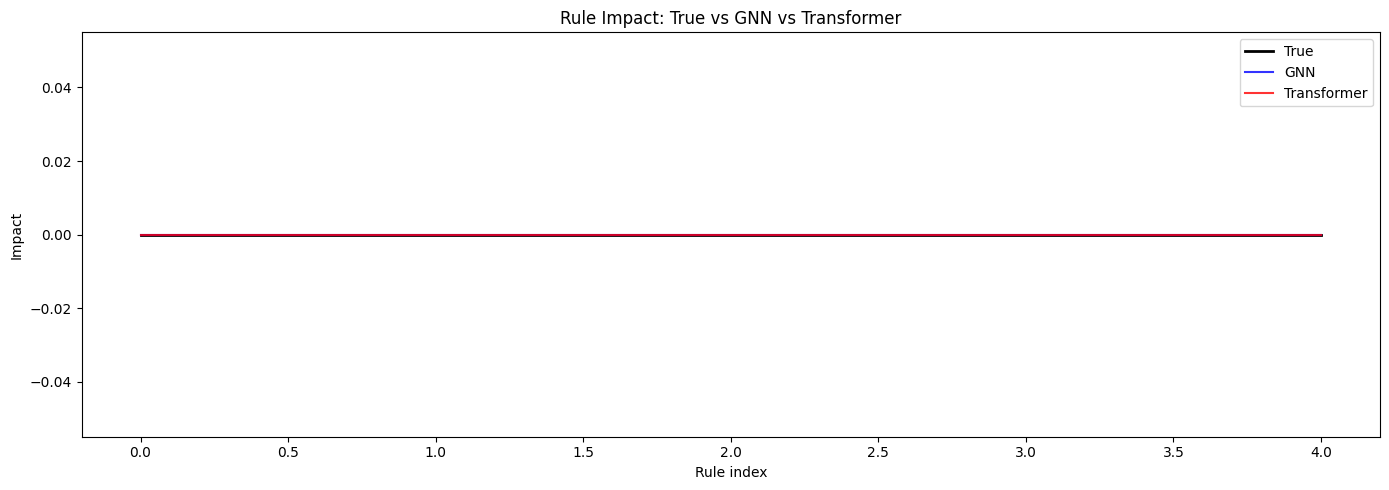

In [60]:
# Plot
fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(purity_comparison))
ax.plot(x, purity_comparison["true_impact"],
        label="True", linewidth=2, color="black")
ax.plot(x, purity_comparison["gnn_impact"],
        label="GNN", linewidth=1.5, color="blue", alpha=0.8)
ax.plot(x, purity_comparison["transformer_impact"],
        label="Transformer", linewidth=1.5, color="red", alpha=0.8)
ax.set_xlabel("Rule index")
ax.set_ylabel("Impact")
ax.set_title("Rule Impact: True vs GNN vs Transformer")
ax.legend()
plt.tight_layout()
plt.savefig("purity_comparison.png", dpi=150)
plt.show()